### Comparison of filament catalogues with eRASS

This notebook studies the overlap of different survey regions, consisting of filament catalogues, with the eROSITA-DE all sky survey.


**Author**: Soumya Shreeram <br/>
**Date created**: 3rd Dec 2021 <br/>
**Last edited**: Spring 2022 <br/>

Import requied packages

In [25]:
# astropy modules
import astropy.units as u
import astropy.io.fits as fits

from astropy.table import Table, Column, join
from astropy.coordinates import SkyCoord
from astropy.cosmology import FlatLambdaCDM, z_at_value

import numpy as np

# system imports
import os
import sys
import importlib as ib
import glob
import gzip

# plotting imports
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

from scipy.stats import norm
from scipy import interpolate
import pandas as pd

Change the default matplotlib params here for the rest of the notebook.

In [18]:
matplotlib.rcParams['agg.path.chunksize'] = 100000
%matplotlib inline
font = {'family' : 'serif',
        'weight' : 'medium',
        'size'   : 16}
matplotlib.rc('font', **font)

bright_colors = sns.color_palette("bright")

The directory where the methods/classes/instances used in this notebook are stored.

In [19]:
import filaments as fo

In [20]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Reloading the imports while developing modules

Initiating one of the filament catalogues that will be used later for stacking purposes.

In [21]:
this_fil_duque21 = fo.Filaments(filament_catalogue_name='Duque_2021_SDSS')
this_fil_tempel14 = fo.Filaments(filament_catalogue_name='Tempel_2014_SDSS')
this_fil_eardley15 = fo.Filaments(filament_catalogue_name='Eardley_2015_GAMA')
this_fil_yenchi17 = fo.Filaments(filament_catalogue_name='Yen_Chi_2017_SDSS')

In [22]:
plot_obj_duque21 = fo.DoPlotFilaments(this_fil_duque21)
plot_obj_tempel14 = fo.DoPlotFilaments(this_fil_tempel14)
plot_obj_eardley15 = fo.DoPlotFilaments(this_fil_eardley15)
plot_obj_yenchi17 = fo.DoPlotFilaments(this_fil_yenchi17)

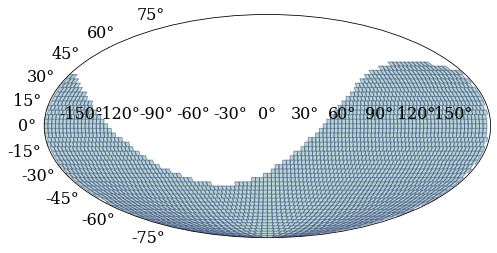

In [14]:
fig = plt.figure(figsize=(8,4.2))
ax = plt.subplot(111, projection="mollweide")

ax = plot_obj_duque21.plot_eRASS_sky(ax)
fig.patch.set_facecolor('white')

INFO:DoPlotFilaments: Plotting Yen_Chi_2017_SDSS on the all sky projection.
INFO:Filaments: Files in the filament catalogue: 
 ['/data53s/shreeram/Filament_stacking/data/Filament_catalogues/Yen_Chi_2017_SDSS/dr12_FMaps_full.txt', '/data53s/shreeram/Filament_stacking/data/Filament_catalogues/Yen_Chi_2017_SDSS/dr12_Fint.txt', '/data53s/shreeram/Filament_stacking/data/Filament_catalogues/Yen_Chi_2017_SDSS/dr12_F_info.txt']


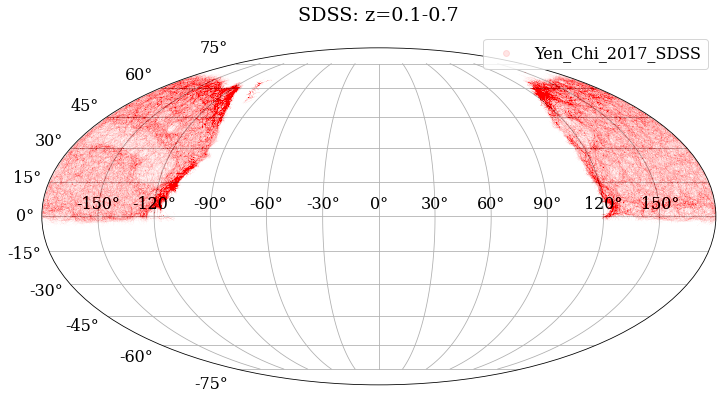

In [37]:
plot_obj_yenchi17.plot_filaments_on_sky(color='r')

INFO:DoPlotFilaments: Plotting Tempel_2014_SDSS on the all sky projection.
INFO:Filaments: Files in the filament catalogue: 
 ['/data53s/shreeram/Filament_stacking/data/Filament_catalogues/Tempel_2014_SDSS/fil_properties.txt', '/data53s/shreeram/Filament_stacking/data/Filament_catalogues/Tempel_2014_SDSS/fil_point_properties.txt']


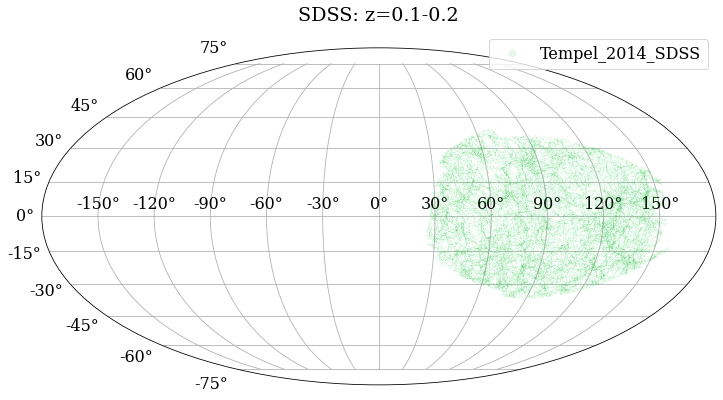

In [27]:
plot_obj_tempel14.plot_filaments_on_sky(color=bright_colors[2], ms=0.1, alpha=0.5)

INFO:DoPlotFilaments: Plotting Eardley_2015_GAMA on the all sky projection.
INFO:Filaments: Files in the filament catalogue: 
 ['/data53s/shreeram/Filament_stacking/data/Filament_catalogues/Eardley_2015_GAMA/GeometricGrid.fits']


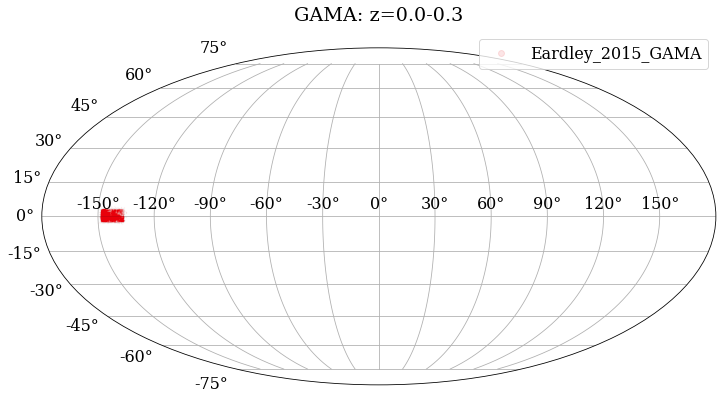

In [18]:
plot_obj_eardley15.plot_filaments_on_sky(color=bright_colors[3], alpha=0.6, ms=0.3)

INFO:DoPlotFilaments: Plotting Duque_2021_SDSS on the all sky projection.
INFO:Filaments:Default param 'which_redshifts=lowz'  


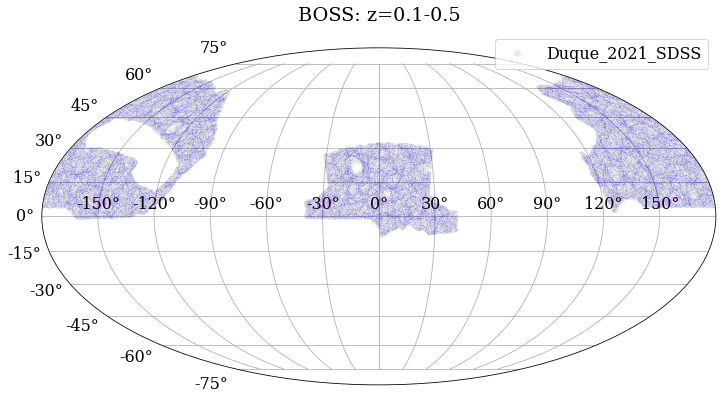

In [35]:
plot_obj_duque21.plot_filaments_on_sky(color=bright_colors[4])

INFO:DoPlotFilaments: Plotting Duque_2021_SDSS on the all sky projection.
INFO:Filaments:Default param 'which_redshifts=lowz'  
INFO:DoPlotFilaments: Plotting Tempel_2014_SDSS on the all sky projection.
INFO:Filaments: Files in the filament catalogue: 
 ['/data53s/shreeram/Filament_stacking/data/Filament_catalogues/Tempel_2014_SDSS/fil_properties.txt', '/data53s/shreeram/Filament_stacking/data/Filament_catalogues/Tempel_2014_SDSS/fil_point_properties.txt']
INFO:DoPlotFilaments: Plotting Yen_Chi_2017_SDSS on the all sky projection.
INFO:Filaments: Files in the filament catalogue: 
 ['/data53s/shreeram/Filament_stacking/data/Filament_catalogues/Yen_Chi_2017_SDSS/dr12_FMaps_full.txt', '/data53s/shreeram/Filament_stacking/data/Filament_catalogues/Yen_Chi_2017_SDSS/dr12_Fint.txt', '/data53s/shreeram/Filament_stacking/data/Filament_catalogues/Yen_Chi_2017_SDSS/dr12_F_info.txt']
INFO:DoPlotFilaments: Plotting Eardley_2015_GAMA on the all sky projection.
INFO:Filaments: Files in the filament c

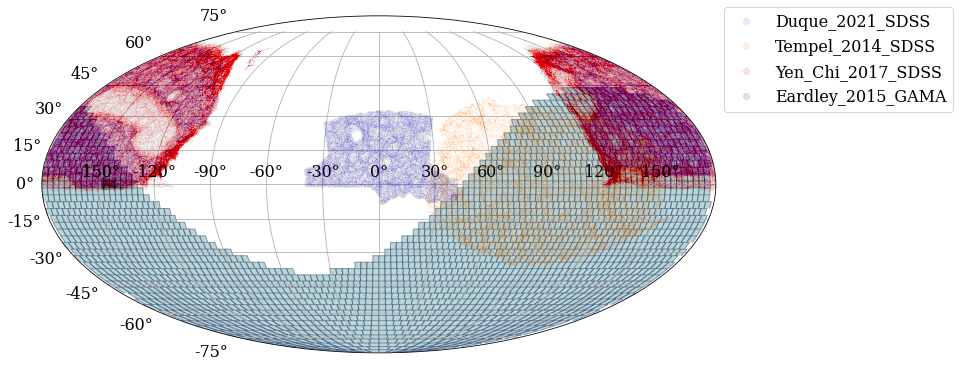

In [24]:
fig = plt.figure(figsize=(14,6.2))
ax = plt.subplot(111, projection="mollweide")

colorblind_colors = sns.color_palette("colorblind")
ax = plot_obj_duque21.plot_filaments(ax, color=bright_colors[4])
ax = plot_obj_tempel14.plot_filaments(ax, color=bright_colors[1], ms=0.1, alpha=0.5)
ax = plot_obj_yenchi17.plot_filaments(ax, color=bright_colors[3], alpha=0.6)
ax = plot_obj_eardley15.plot_filaments(ax, color='k')

ax = plot_obj_duque21.plot_eRASS_sky(ax)
ax.grid()

l = ax.legend(bbox_to_anchor=(1., 1.05))
for legend_handle in l.legendHandles:
    legend_handle._legmarker.set_markersize(12)
    legend_handle.set_alpha(1)
ax.set_title("")
fig.patch.set_facecolor('white')
fig.savefig(f"{plot_obj_duque21.image_dir}/all_catalogues_overplot_without_bkg.png", format='png')

INFO:DoPlotFilaments: Plotting Tempel_2014_SDSS on the all sky projection.
INFO:Filaments: Files in the filament catalogue: 
 ['/data53s/shreeram/Filament_stacking/data/Filament_catalogues/Tempel_2014_SDSS/fil_properties.txt', '/data53s/shreeram/Filament_stacking/data/Filament_catalogues/Tempel_2014_SDSS/fil_point_properties.txt']
INFO:Filaments: Files in the filament catalogue: 
 ['/data53s/shreeram/Filament_stacking/data/Filament_catalogues/Tempel_2014_SDSS/fil_properties.txt', '/data53s/shreeram/Filament_stacking/data/Filament_catalogues/Tempel_2014_SDSS/fil_point_properties.txt']
INFO:DoPlotFilaments: We have overlapping filaments with the eRASS sky!
INFO:DoPlotFilaments: Number of filaments found is 13237
INFO:DoPlotFilaments: Number of filaments longer than 5 Mpc: 8389


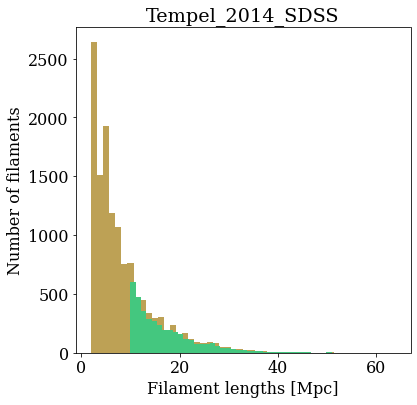

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

# eRASS sky tile edges 
ax = plot_obj_tempel14.plot_filament_lengths_Tempel14(ax)
fig.patch.set_facecolor('white')

### Now deprecated (past work)

Plot the eRASS sky tiles as closed polygons

Now we plot the filament catalog for different redshifts bins. The catalogue 

In [ ]:
filament_dir = os.path.join('/data53s', 'shreeram', 'Filament_stacking', 'data')       
filament_cat_dir = os.path.join(filament_dir, 'Block1.csv')
filament_catalogue = pd.read_csv(filament_cat_dir)

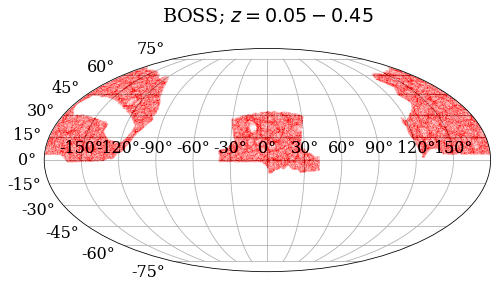

In [8]:
fig = plt.figure(figsize=(8,4.2))
ax = plt.subplot(111, projection="mollweide")
ax, ra_fil1, dec_fil1 = fil_cat_Javier.plotFilaments(ax, filename='Block1.csv', color_fil='r')
       
ax.grid()
fig.patch.set_facecolor('white')

Default catalogue set to  BOSS CMASS; $z=0.45-0.7$


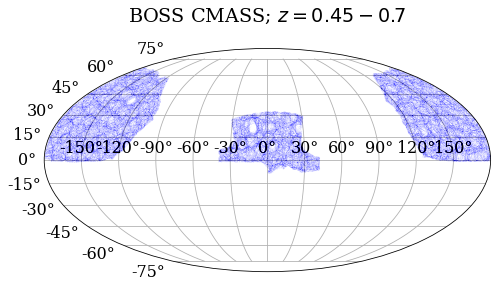

In [9]:
fig = plt.figure(figsize=(8,4.2))
ax = plt.subplot(111, projection="mollweide")
fil_cat_Javier.decideTitleLabel(filename='Block2.csv')
ax, ra_fil2, dec_fil2 = fil_cat_Javier.plotFilaments(ax, filename='Block2.csv', color_fil='b')
       
ax.grid()
fig.patch.set_facecolor('white')

Default catalogue set to  BOSS+eBOSS; $z=0.6-2.2$


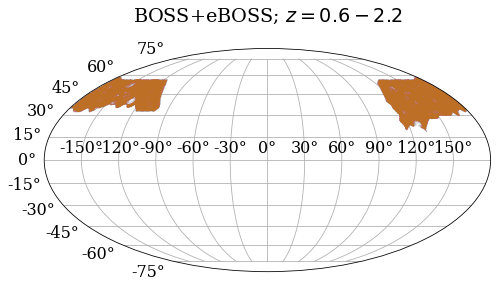

In [10]:
fig = plt.figure(figsize=(8,4.2))
ax = plt.subplot(111, projection="mollweide")
fil_cat_Javier.decideTitleLabel(filename='Block3.csv')
ax, ra_fil3, dec_fil3 = fil_cat_Javier.plotFilaments(ax, filename='Block3.csv', color_fil='#bd6f26')
   
ax.grid()
fig.patch.set_facecolor('white')

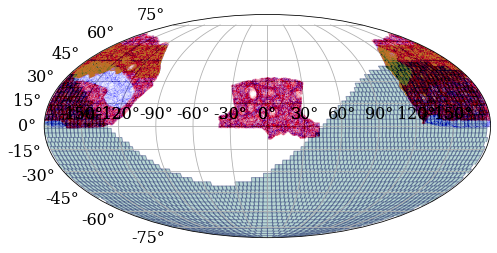

In [11]:
fig = plt.figure(figsize=(8,4.2))
ax = plt.subplot(111, projection="mollweide")

# eRASS sky tile edges 
ax = fil_cat_Javier.ploteRASSsky(ax)

# plot BOSS LOWZ, CMASS, BOSS+eBOSS
ax.plot(ra_fil1, dec_fil1, '.', c='r', alpha=0.1, ms=0.03)
ax.plot(ra_fil2, dec_fil2, '.', c='b', alpha=0.1, ms=0.03)
ax.plot(ra_fil3, dec_fil3, '.', c='#bd6f26', alpha=0.1, ms=0.03)

fig.patch.set_facecolor('white')
ax.grid()

Checking the number of filament points falling the eRASS-DE sky

In [12]:
def getOverlapRegions(fil_cat_Javier, ra_fil1, dec_fil1):
    fil_idx_eRASS_tiles1 = fil_cat_Javier.overlappingFilaments(ra_fil1, dec_fil1)
    overlap_fil1 = np.concatenate(fil_idx_eRASS_tiles1, axis=0)
    overlap_fil1 = overlap_fil1[overlap_fil1 != None]
    return fil_idx_eRASS_tiles1, overlap_fil1

In [13]:
fil_idx_eRASS_tiles1, overlap_fil1 = getOverlapRegions(fil_cat_Javier, ra_fil1, dec_fil1)
fil_idx_eRASS_tiles2, overlap_fil2 = getOverlapRegions(fil_cat_Javier, ra_fil2, dec_fil2)
fil_idx_eRASS_tiles3, overlap_fil3 = getOverlapRegions(fil_cat_Javier, ra_fil3, dec_fil3)

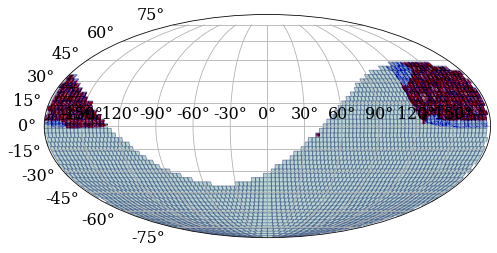

In [14]:
fig = plt.figure(figsize=(8,4.2))
ax = plt.subplot(111, projection="mollweide")

# eRASS sky tile edges 
ax = fil_cat_Javier.ploteRASSsky(ax)

# plot overlapping regions from the BOSS LOWZ, CMASS, BOSS+eBOSS
ax.plot(ra_fil1[list(overlap_fil1)], dec_fil1[list(overlap_fil1)], '.', c='r', alpha=0.1, ms=0.03)
ax.plot(ra_fil2[list(overlap_fil2)], dec_fil2[list(overlap_fil2)], '.', c='b', alpha=0.1, ms=0.03)

fig.patch.set_facecolor('white')
ax.grid()
plt.savefig('../images/overlaps_Javier_block12.png')
plt.savefig('../images/overlaps_Javier__block12.pdf', dpi=150)

The above plot shows the overlapping regions of the LOWZ and CMASS regions with the eRASS-DE sky. This is the part of the filament catalogue that can be used for stacking filaments. TODO: check out the overlap of the eRASS-DE sky with other filament catalogues.